In [61]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
conn = sqlite3.connect('sales_data.db')

In [23]:
cursor = conn.cursor()

In [24]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS full_sales(
sale_Id INTEGER PRIMRY KEY,
branch TEXT,
city TEXT,
customer_type TEXT,
gender TEXT,
product_name TEXT,
product_category TEXT,
unit_price REAL,
quantity INTEGER,
tax REAL,
total_price REAL,
reward_points INTEGER
)
""")

In [25]:
conn.commit()
conn.close()

In [26]:
conn = sqlite3.connect("sales_data.db")

In [27]:
cursor = conn.cursor()

In [29]:
data = [
    (1, 'A', 'New York', 'Member', 'Male', 'Shampoo', 'Personal Care', 5.5, 3, 1.16, 17.66, 1),
    (2, 'B', 'Los Angeles', 'Normal', 'Female', 'Notebook', 'Stationery', 2.75, 10, 1.93, 29.43, 0),
    (3, 'A', 'New York', 'Member', 'Female', 'Apple', 'Fruits', 1.2, 15, 1.26, 19.26, 1),
    (4, 'A', 'Chicago', 'Normal', 'Male', 'Detergent', 'Household', 7.8, 5, 2.73, 41.73, 0),
    (5, 'B', 'Los Angeles', 'Member', 'Female', 'Orange Juice', 'Beverages', 3.5, 7, 1.72, 26.22, 2),
    (6, 'A', 'Chicago', 'Normal', 'Male', 'Shampoo', 'Stationery', 11.24, 9, 7.08, 108.24, 0),
    (7, 'A', 'Chicago', 'Normal', 'Male', 'Shampoo', 'Personal Care', 10.71, 1, 0.75, 11.46, 0),
    (8, 'B', 'Los Angeles', 'Normal', 'Female', 'Shampoo', 'Household', 18.23, 9, 11.48, 175.55, 0),
    (9, 'A', 'Chicago', 'Member', 'Female', 'Apple', 'Fruits', 14.15, 20, 19.81, 302.81, 30),
    (10, 'B', 'Los Angeles', 'Member', 'Male', 'Shampoo', 'Fruits', 18.42, 19, 24.5, 374.48, 37),
    (11, 'A', 'Chicago', 'Normal', 'Male', 'Detergent', 'Beverages', 9.32, 7, 4.57, 69.81, 0),
    (12, 'B', 'Los Angeles', 'Member', 'Male', 'Orange Juice', 'Household', 6.89, 12, 5.79, 88.47, 8),
    (13, 'A', 'New York', 'Normal', 'Female', 'Orange Juice', 'Household', 3.29, 4, 0.92, 14.08, 0),
    (14, 'B', 'Los Angeles', 'Member', 'Female', 'Apple', 'Fruits', 8.81, 5, 3.08, 47.13, 4),
    (15, 'B', 'Los Angeles', 'Normal', 'Female', 'Apple', 'Beverages', 19.48, 3, 4.09, 62.53, 0),
    (16, 'B', 'Los Angeles', 'Normal', 'Male', 'Notebook', 'Stationery', 5.55, 8, 3.11, 47.51, 0),
    (17, 'B', 'Los Angeles', 'Member', 'Female', 'Apple', 'Personal Care', 2.13, 2, 0.3, 4.56, 0),
    (18, 'B', 'Los Angeles', 'Normal', 'Male', 'Notebook', 'Fruits', 13.26, 15, 13.92, 212.82, 0),
    (19, 'A', 'New York', 'Member', 'Male', 'Apple', 'Beverages', 19.59, 2, 2.74, 41.92, 4),
    (20, 'A', 'Chicago', 'Normal', 'Male', 'Detergent', 'Personal Care', 6.98, 8, 3.91, 59.75, 0)
]

In [30]:
cursor.executemany("""
INSERT INTO full_sales(
sale_id, branch, city, customer_type, gender, product_name, product_category, unit_price, quantity, tax, total_price, reward_points
) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""", data)

In [31]:
cursor.execute("PRAGMA table_info(full_sales)")
columns = cursor.fetchall()

print("Columns names in 'full_sales':")
for col in columns:
    print(col[1])

Columns names in 'full_sales':
sale_Id
branch
city
customer_type
gender
product_name
product_category
unit_price
quantity
tax
total_price
reward_points


In [32]:
cursor.execute("SELECT COUNT(*) FROM full_sales")
print("Row count:", cursor.fetchone()[0])

Row count: 20


In [52]:
query1 = """
SELECT product_category, 
       SUM(quantity) AS total_quantity, 
       SUM(total_price) AS total_revenue
FROM full_sales
GROUP BY product_category
ORDER BY total_revenue DESC
"""
cursor.execute(query1)
df = pd.read_sql_query(query1, conn)
print(df)

  product_category  total_quantity  total_revenue
0           Fruits              74         956.50
1        Household              30         319.83
2        Beverages              19         200.48
3       Stationery              27         185.18
4    Personal Care              14          93.43


In [70]:
query2 = """
SELECT city, customer_type, 
       ROUND(AVG(total_price), 2) AS avg_purchase
FROM full_sales
GROUP BY city, customer_type
ORDER BY avg_purchase DESC
"""
cursor.execute(query2)
df = pd.read_sql_query(query2, conn)
print(df)

          city customer_type  avg_purchase
0      Chicago        Member        302.81
1  Los Angeles        Member        108.17
2  Los Angeles        Normal        105.57
3      Chicago        Normal         58.20
4     New York        Member         26.28
5     New York        Normal         14.08


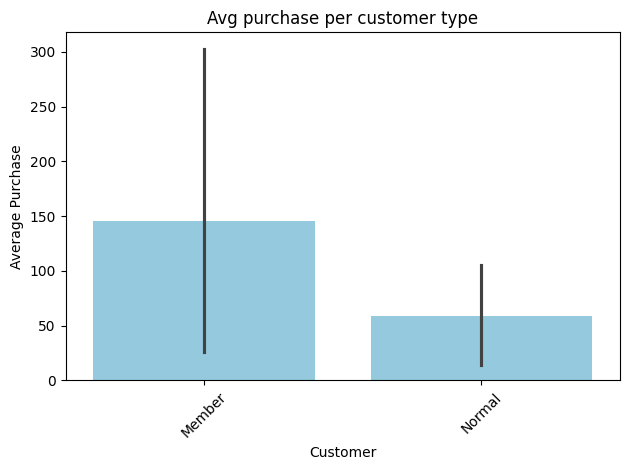

In [72]:
plt.title("Avg purchase per customer type")
sns.barplot(data=df, y="avg_purchase", x="customer_type", color="skyblue")
plt.xlabel("Customer")
plt.ylabel("Average Purchase")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
query3 = """
SELECT product_name, 
       SUM(total_price) AS total_revenue
FROM full_sales
GROUP BY product_name
ORDER BY total_revenue DESC
LIMIT 5
"""
cursor.execute(query3)
df = pd.read_sql_query(query3, conn)
print(df)

   product_name  total_revenue
0       Shampoo         687.39
1         Apple         478.21
2      Notebook         289.76
3     Detergent         171.29
4  Orange Juice         128.77


In [60]:
query4 = """
SELECT gender, customer_type, 
       SUM(reward_points) AS total_points
FROM full_sales
GROUP BY gender, customer_type
ORDER BY total_points DESC
"""
cursor.execute(query4)
df = pd.read_sql_query(query4, conn)
print(df)

   gender customer_type  total_points
0    Male        Member            50
1  Female        Member            37
2  Female        Normal             0
3    Male        Normal             0


In [50]:
query5 = """
SELECT city, 
       SUM(total_price) AS total_sales
FROM full_sales
GROUP BY city
ORDER BY total_sales DESC
LIMIT 1
"""
cursor.execute(query5)
print("City with highest sales:", cursor.fetchone())

City with highest sales: ('Los Angeles', 1068.7)


In [66]:
df = pd.read_sql_query(query1, conn)
print(df)

  product_category  total_quantity  total_revenue
0           Fruits              74         956.50
1        Household              30         319.83
2        Beverages              19         200.48
3       Stationery              27         185.18
4    Personal Care              14          93.43


In [67]:
print(df.columns)
print(df.head())

Index(['product_category', 'total_quantity', 'total_revenue'], dtype='object')
  product_category  total_quantity  total_revenue
0           Fruits              74         956.50
1        Household              30         319.83
2        Beverages              19         200.48
3       Stationery              27         185.18
4    Personal Care              14          93.43


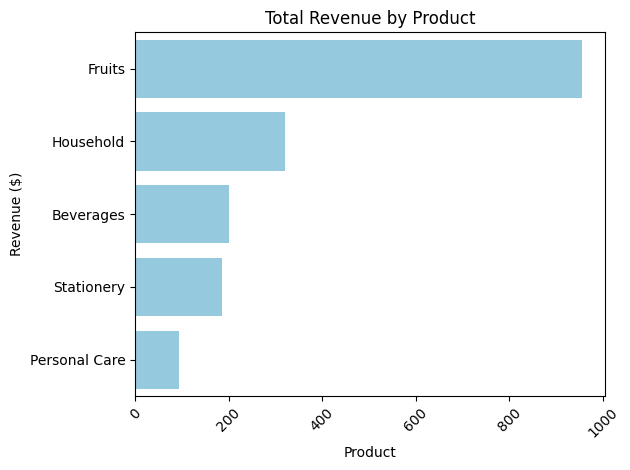

In [69]:
plt.title("Total Revenue by Product")
sns.barplot(data=df, x="total_revenue", y="product_category", color="skyblue")
plt.ylabel("Revenue ($)")
plt.xlabel("Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# SUMMARY
I created a small SQLite database (sales_data.db) and added a table called full_sales with 20 manually entered rows of sales data.

After fixing a small column name typo, I checked the table structure to make sure everything was set up correctly.

I ran several SQL queries to explore the data — like checking total revenue by product, reward points by gender, and average prices.

I imported the SQL query results into Pandas so I could work with them easily in Python.

Finally, I visualized the data with a clean bar chart showing total revenue by product using Seaborn and Matplotlib.